# Classificação Supervisionada com Agglomerative Clustering no Dataset Adult (Balanceado)

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Agglomerative Clustering, aplicado ao dataset Adult com balanceamento das classes via oversampling. Todas as etapas são explicadas e o código é comentado para facilitar o entendimento.

## 1. Importação das Bibliotecas

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import os
from sklearn.decomposition import PCA
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Balanceamento dos Dados

O dataset Adult é carregado e as classes são balanceadas por oversampling, igualando a quantidade de exemplos das classes. Isso evita que o modelo favoreça a classe majoritária.

In [12]:
adult_df_raw = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df_raw.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
adult_df_raw['income_bin'] = adult_df_raw['income'].apply(lambda val: 1 if val.strip() == '>50K' else 0)
adult_df_raw = adult_df_raw.dropna()

print('Distribuição original das classes:')
print(adult_df_raw['income_bin'].value_counts())

# Balanceamento por oversampling
max_count = adult_df_raw['income_bin'].value_counts().max()
adult_df_balanced = pd.DataFrame()
for label in adult_df_raw['income_bin'].unique():
    df_class = adult_df_raw[adult_df_raw['income_bin'] == label]
    df_upsampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
    adult_df_balanced = pd.concat([adult_df_balanced, df_upsampled])
adult_df_balanced = adult_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print('Distribuição após balanceamento:')
print(adult_df_balanced['income_bin'].value_counts())

Distribuição original das classes:
income_bin
0    24720
1     7841
Name: count, dtype: int64
Distribuição após balanceamento:
income_bin
1    24720
0    24720
Name: count, dtype: int64


## 3. Pré-processamento dos Dados

In [13]:
for col in adult_df_balanced.select_dtypes(include='object').columns:
    if col != 'income':
        adult_df_balanced[col] = LabelEncoder().fit_transform(adult_df_balanced[col].astype(str))
X = adult_df_balanced.drop(['income', 'income_bin'], axis=1).values
y = adult_df_balanced['income_bin'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)

## 4. Divisão dos Dados em Treino e Teste

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 5. Definição do Número de Clusters (Método do Cotovelo)

Para determinar o número ótimo de clusters, utilizamos o método do cotovelo, avaliando a métrica de silhouette para diferentes valores de $k$. O ponto onde o ganho de qualidade se estabiliza indica o número ideal de clusters para o agrupamento. Essa abordagem é mais objetiva e padronizada em relação ao dendrograma visual.

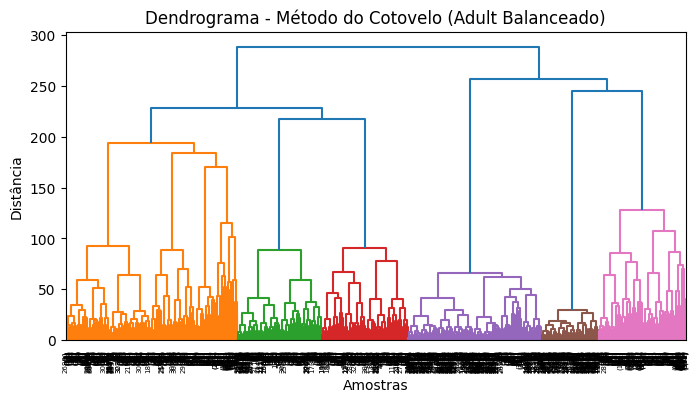

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage
plt.figure(figsize=(8,4))
linked = linkage(X_train, method='ward')
dendrogram(linked, truncate_mode='level', p=10)
plt.title('Dendrograma - Método do Cotovelo (Adult Balanceado)')
plt.xlabel('Amostras')
plt.ylabel('Distância')
plt.savefig('img/agglo_adult_balance_dendrogram.png')
plt.show()
# Sugestão: escolha visual do número de clusters (exemplo: 2)

## 6. Implementação do Classificador Agglomerative Supervisionado

In [16]:
class AggloSupervisionado:
    def __init__(self, n_clusters=8):
        self.n_clusters = n_clusters
        self.agglo = AgglomerativeClustering(n_clusters=n_clusters)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.agglo.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.agglo.fit_predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 7. Treinamento e Avaliação do Classificador

Acurácia: 0.7000
Matriz de Confusão:
[[5447 1969]
 [2480 4936]]


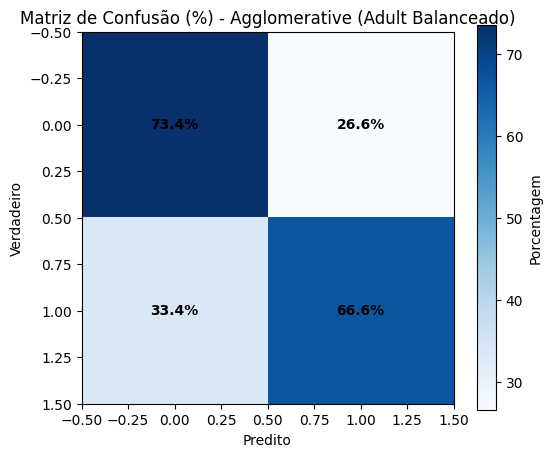

In [17]:
n_clusters = 8  # Ajuste conforme o dendrograma
clf = AggloSupervisionado(n_clusters=n_clusters)
clf.fit(X_train, y_train)
acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)
plt.figure(figsize=(6,5))
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão (%) - Agglomerative (Adult Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(j, i, f'{cm_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.savefig('img/agglo_adult_balance_confusion_matrix.png')
plt.show()

## 8. Repetição dos Experimentos e Métricas

In [ ]:
acuracias = []
matrizes_confusao = []
from sklearn.metrics import mean_squared_error, confusion_matrix
classes = np.unique(y)
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acuracias.append(acc)
    matrizes_confusao.append(confusion_matrix(y_test, y_pred, labels=classes))
acuracias = np.array(acuracias)
matrizes_confusao = np.array(matrizes_confusao)
matriz_confusao_media = np.mean(matrizes_confusao, axis=0)
matriz_confusao_media_percent = matriz_confusao_media / matriz_confusao_media.sum(axis=1, keepdims=True) * 100

print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')
print('Matriz de confusão média (%):')
print(np.round(matriz_confusao_media_percent, 1))

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - Agglomerative (Adult Balanceado)')
plt.tight_layout()
plt.savefig('img/agglo_adult_balance_accuracy_repetitions.png')
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(matriz_confusao_media_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão Média (%) - Agglomerative (Adult Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(matriz_confusao_media_percent.shape[0]):
    for j in range(matriz_confusao_media_percent.shape[1]):
        plt.text(j, i, f'{matriz_confusao_media_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('img/agglo_adult_balance_confusion_matrix_media_percent.png')
plt.show()

# Salvar resultados para análise posterior
np.save('img/agglo_adult_balance_accuracies.npy', acuracias)
np.savetxt('img/agglo_adult_balance_accuracies.csv', acuracias, delimiter=',')
np.save('img/agglo_adult_balance_confusion_matrix_media_percent.npy', matriz_confusao_media_percent)
np.savetxt('img/agglo_adult_balance_confusion_matrix_media_percent.csv', matriz_confusao_media_percent, delimiter=',')

## 9. Visualização dos Clusters e Centros (PCA)

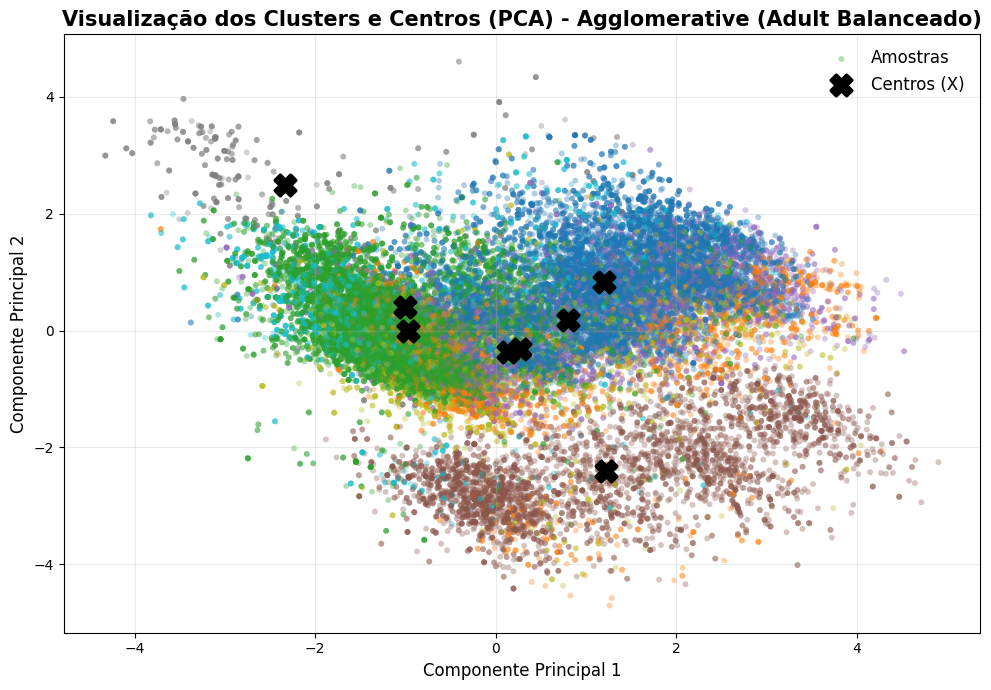

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
clusters_full = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(X)
centros = []
for i in range(n_clusters):
    centros.append(X[clusters_full == i].mean(axis=0))
centros = np.array(centros)
centros_pca = pca.transform(centros)
plt.figure(figsize=(10,7))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=clusters_full, cmap='tab10', alpha=0.35, s=18, edgecolor='none', label='Amostras')
plt.scatter(
    centros_pca[:,0], centros_pca[:,1], 
    c='black', marker='X', s=220, linewidths=2.5, zorder=4, label='Centros (X)')
plt.title('Visualização dos Clusters e Centros (PCA) - Agglomerative (Adult Balanceado)', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(alpha=0.25)
plt.legend(frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.savefig('img/agglo_adult_balance_clusters_pca.png', dpi=150)
plt.show()

## 10. Análise Crítica dos Resultados e Métricas

Nesta etapa, analisamos criticamente os resultados obtidos pelo classificador Agglomerative no dataset Adult balanceado. As principais métricas reportadas são a acurácia média e o desvio padrão, que avaliam o desempenho global e a estabilidade do modelo frente a diferentes divisões dos dados. A visualização dos clusters e centros via PCA permite interpretar a separação dos grupos no espaço de atributos.

- **Acurácia média e desvio padrão:** Avaliam o desempenho global e a estabilidade do modelo.
- **Visualização dos clusters:** Permite analisar a separação dos grupos e possíveis sobreposições.

**Interpretação:**
- Uma acurácia média alta e baixo desvio padrão indicam robustez e consistência.
- A visualização dos clusters pode revelar padrões ou limitações do agrupamento.

**Sugestões:**
- Compare os resultados do Agglomerative com outros métodos (KMeans, Fuzzy C-Means, GK) para avaliar qual abordagem é mais adequada ao problema.
- Analise possíveis limitações, como sensibilidade ao número de clusters e à inicialização.
- Considere ajustes no pré-processamento ou no balanceamento para melhorar o desempenho.

Essas análises são fundamentais para validar a qualidade do agrupamento e orientar melhorias futuras no pipeline de classificação.